<a href="https://colab.research.google.com/github/Ricardo428/Red-Convolutiva/blob/main/Modelo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torch import nn,optim


# Realizamos la transformación para asegurar uniformidad en el conjunto
transform = transforms.Compose([
    transforms.Resize((192, 192)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


ruta = '/content/drive/MyDrive/dataset'

# Cargamos el dataset
train_data = datasets.ImageFolder(root=ruta + "/train",transform = transform)
test_data = datasets.ImageFolder(root=ruta + "/test",transform = transform)
valid_data = datasets.ImageFolder(root=ruta + "/validation",transform = transform)


# Imprime los valores máximo y mínimo de un píxel en la primera imagen (después de la normalización)
# Obtenemos el valor máximo y mínimo, que están en el rango de [-1, 1]
print("Maximo valor de la imagen:",train_data[0][0].squeeze().max())
print("Minimo valor de la imagen:",train_data[0][0].squeeze().min())

# Informacion del dataset
print("\n--- Información del dataset ---")
print(f"Clases encontradas: {train_data.classes}")
print(f"Número de clases: {len(train_data.classes)}")
print(f"Num imagenes training: {len(train_data)}")
print(f"Num imagenes test: {len(test_data)}")
print(f"Num imagenes valid: {len(valid_data)}")

# Empaquetamos las imagenes en lotes de 32
train_loader = DataLoader(train_data,shuffle=True,batch_size=32)
test_loader = DataLoader(test_data,shuffle=False,batch_size=32)
valid_loader = DataLoader(valid_data,shuffle=False,batch_size=32)


Maximo valor de la imagen: tensor(1.)
Minimo valor de la imagen: tensor(-1.)

--- Información del dataset ---
Clases encontradas: ['bus', 'car', 'motorcycle', 'train', 'truck']
Número de clases: 5
Num imagenes training: 5418
Num imagenes test: 708
Num imagenes valid: 709


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Vehiculos(nn.Module):
  def __init__(self):
    super(Vehiculos, self).__init__()

    # Tenemos 3 capas convolucionales para detectar patrones
    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)

    # Una capa de MaxPooling para la reducción de la imagen
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

    # Apagado de la mitad de las neuronas evitando memorización
    self.dropout = nn.Dropout(0.5)

    # Tenemos 2 capas fully-connected para la clasificación
    self.fc1 = nn.Linear(128 * 24 * 24, 128)
    self.fc2 = nn.Linear(128, 5)

  def forward(self, x):

    # Aplicamos las capas convolucionales con su función de activación y un pooling
    x = self.conv1(x)
    x = F.relu(x)
    x = self.pool(x)

    x = self.conv2(x)
    x = F.relu(x)
    x = self.pool(x)

    x = self.conv3(x)
    x = F.relu(x)
    x = self.pool(x)

    # Aplanamos a un vector (1D) para las capas lineales
    x = x.view(-1, 128 * 24 * 24)

    # Aplicamos dropout antes de la primera capa fully-connected
    x = self.dropout(x)

    # Aplicamos las capas fully-connected
    x = self.fc1(x)
    x = F.relu(x)
    x = self.dropout(x)
    x = self.fc2(x)

    return x

In [ ]:
# Instanciación de  la red
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Usando {device}')
net = Vehiculos().to(device)

# Definimos la función de pérdida y el optimizador
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(),lr=0.001)

Usando cuda


In [ ]:
import torch
import torch.nn.functional as F

def evaluate(model, loader, criterion, device):

    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Cálculo de la pérdida
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Cálculo de aciertos
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    # Resultados finales
    avg_loss = running_loss / len(loader)
    acc = 100.0 * correct / total if total > 0 else 0.0

    return avg_loss, acc

In [ ]:
# Entrenamiento de la red
num_epochs = 15

# Almacenamiento de resultados
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [],   'val_acc': [],
}

for epoch in range(num_epochs):
  epoch_loss = 0.0
  correct = 0
  total = 0

  net.train()
  for i, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    # Cálculo de las salidas (forward)
    outputs = net(images)

    # Cálculo de la perdida
    loss = loss_fn(outputs, labels)

    # Cálculo de gradientes(backward)
    loss.backward()

    # Actualizar los pesos
    optimizer.step()

    # Reseteo de los gradientes
    optimizer.zero_grad()

    # Acumular la pérdida
    epoch_loss += loss.item()

    # Cálculo de aciertos en el entrenamiento
    _, predicted = torch.max(outputs, 1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  # Resultados del entrenamiento
  epoch_train_loss = epoch_loss / len(train_loader)
  epoch_train_acc = 100.0 * correct / total

  # Cálculo de aciertos y pérdida (Validation)
  epoch_val_loss, epoch_val_acc = evaluate(net, valid_loader, loss_fn, device)

  # Historial
  history['train_loss'].append(epoch_train_loss)
  history['train_acc'].append(epoch_train_acc)

  history['val_loss'].append(epoch_val_loss)
  history['val_acc'].append(epoch_val_acc)

  print(f"[Ep {epoch+1}] "
        f"Train loss: {epoch_train_loss:.3f} accuracy: {epoch_train_acc:.1f}% | "
        f"Val loss: {epoch_val_loss:.3f} accuracy: {epoch_val_acc:.1f}%")


[Ep 1] Train loss: 1.458 accuracy: 36.3% | Val loss: 1.299 accuracy: 47.8%
[Ep 2] Train loss: 1.160 accuracy: 55.0% | Val loss: 1.107 accuracy: 57.4%
[Ep 3] Train loss: 0.983 accuracy: 62.6% | Val loss: 0.935 accuracy: 65.4%
[Ep 4] Train loss: 0.831 accuracy: 68.4% | Val loss: 0.821 accuracy: 70.4%
[Ep 5] Train loss: 0.750 accuracy: 71.3% | Val loss: 0.797 accuracy: 70.9%
[Ep 6] Train loss: 0.637 accuracy: 75.7% | Val loss: 0.828 accuracy: 70.8%
[Ep 7] Train loss: 0.565 accuracy: 78.7% | Val loss: 0.777 accuracy: 71.8%
[Ep 8] Train loss: 0.513 accuracy: 81.0% | Val loss: 0.755 accuracy: 73.3%
[Ep 9] Train loss: 0.459 accuracy: 82.7% | Val loss: 0.893 accuracy: 70.4%
[Ep 10] Train loss: 0.413 accuracy: 84.8% | Val loss: 0.828 accuracy: 73.1%
[Ep 11] Train loss: 0.334 accuracy: 87.8% | Val loss: 0.885 accuracy: 72.5%
[Ep 12] Train loss: 0.307 accuracy: 88.3% | Val loss: 0.949 accuracy: 72.4%
[Ep 13] Train loss: 0.302 accuracy: 88.9% | Val loss: 0.940 accuracy: 73.5%
[Ep 14] Train loss: 0

In [ ]:
correct = 0
total = 0

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the model: {100 * correct / total}%')


Accuracy of the model: 74.43502824858757%


## Resultados
En el desarrollo de las épocas tenemos 2 métricas de cada conjunto (pérdida y precisión).Estas nos dejan ver el comportamiento de la red durante su entrenamiento.
Podemos observar que la red aprende perfectamente con los datos del entrenamiento la pérdida disminuye y la precisión aumenta, por lo que la red está siendo capaz reconocer mejor los patrones de las imagenes

Por otro lado, la métrica de validación mejora durante las primeras épocas, esto nos dice que el modelo esta generalizando bien durante el entrenamineto

Sin embargo, llega un momento en las epocas donde la pérdida de validación suben y luego vuelve a bajar, estamos observando un fenomeno de Overfitting o sobreajuste.Esto demuestra que llegado una época determinada el modelo memoriza los datos del entrenamiento y no generaliza bien para las imagenes de validación

Finalmente vemos una précisión de 74.4% en el conjunto de test que tiene imagenes nos vistas durante el entrenamiento

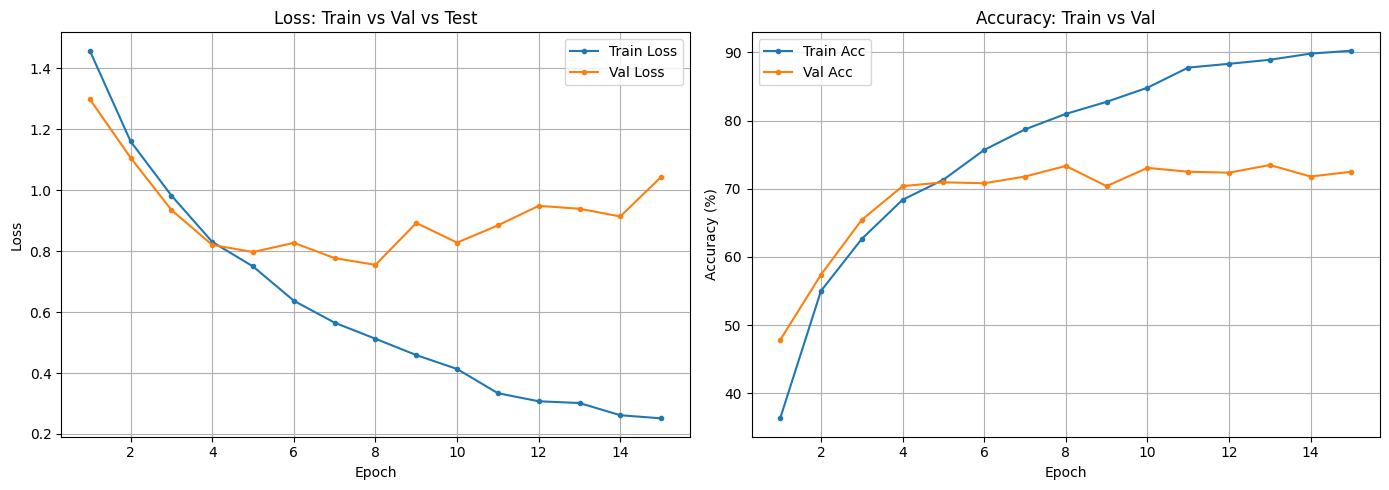

In [ ]:

import matplotlib.pyplot as plt


epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], label='Train Loss', marker='.')
plt.plot(epochs, history['val_loss'],   label='Val Loss',   marker='.')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss: Train vs Val vs Test')
plt.legend()
plt.grid(True)

# Gráfico de precisión
plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], label='Train Acc', marker='.')
plt.plot(epochs, history['val_acc'],   label='Val Acc',   marker='.')

plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy: Train vs Val')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##Interpretación de la gráfica

Tenemos dos gráficas una con la pérdida y otra con la precisión de los dos conjuntos

En la gráfica de pérdida se puede observar una disminución constante de la perdida del entrenamiento.Pero en el caso de validacion se mantiene relativamente alto incluso empeorando y como se dijo anteriormente se ve un caso de overfiting

La gráfica de precisión, complementa esta interpretación.La train accuracy aumenta de forma constante hasta superar el 90 %, lo que confirma que el modelo aprende de los ejemplos de entrenamiento. No obstante, en la validacion las primeras épocas mejora hasta situarse alrededor del 73–75 %, pero después se estabiliza y no continúa aumentando pese a que la precisión del entrenamiento sigue creciendo.

##Matrices de confusión

A continuación vemos las matrices de confusión del entrenamiento, test  y validación que nos dejan analizar con mayor detalle el comportamiento con cada una de las clases y asi ver que clase le cuesta más clasificar

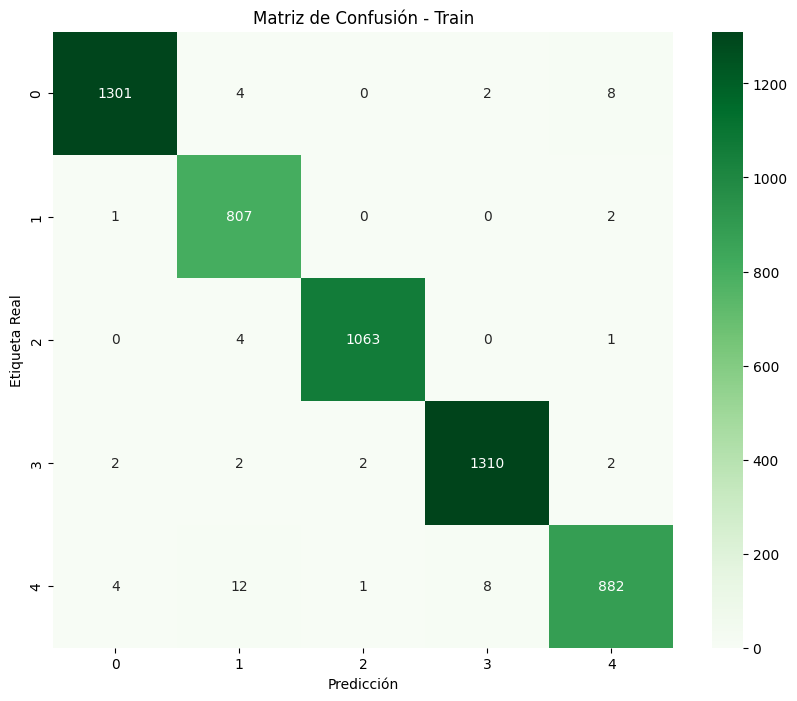

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

net.eval()

all_preds_test = []
all_labels_test = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Train')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

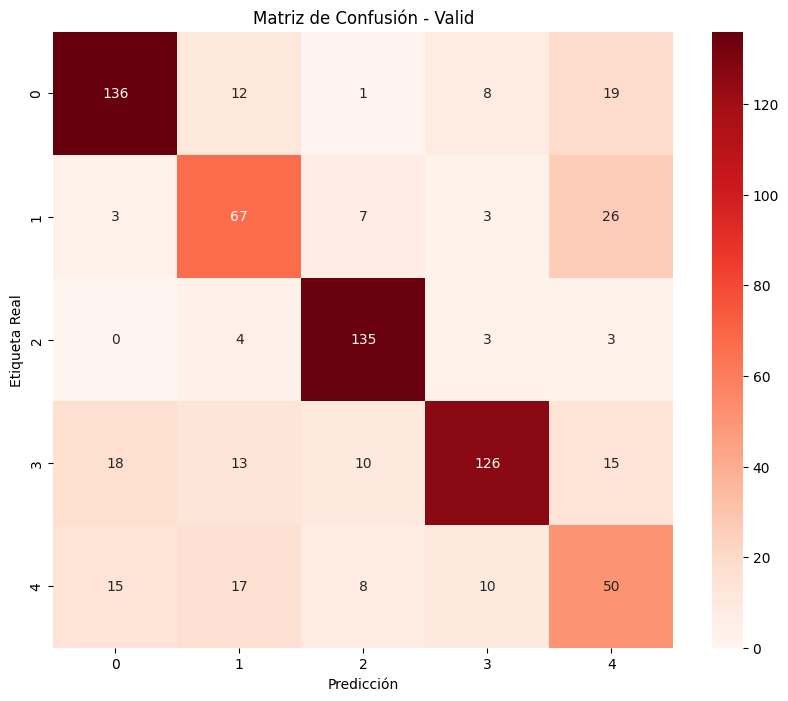

In [ ]:
net.eval()

all_preds_test = []
all_labels_test = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in valid_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_test.extend(predicted.cpu().numpy())
        all_labels_test.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_test = confusion_matrix(all_labels_test, all_preds_test)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Reds')
plt.title('Matriz de Confusión - Valid')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

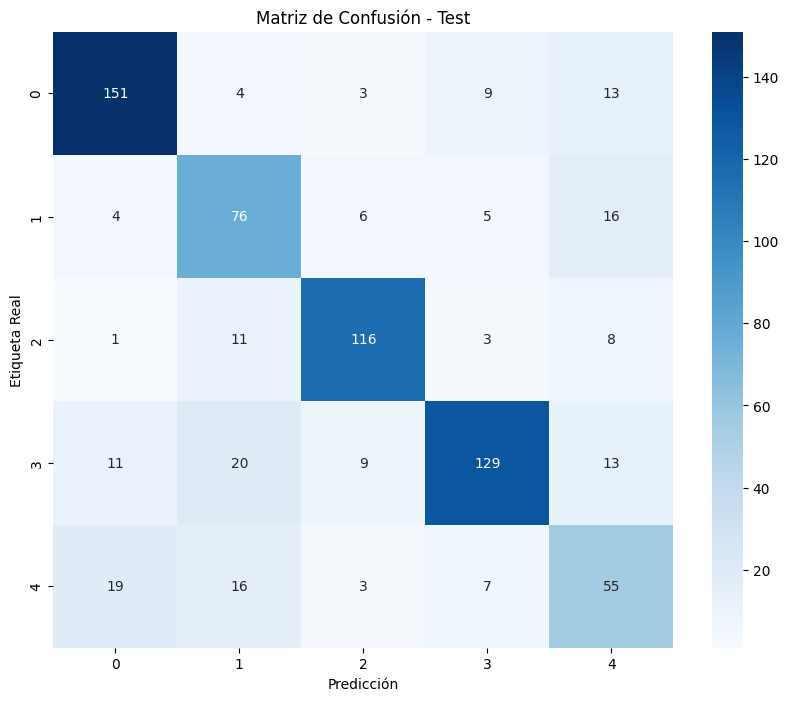

In [ ]:


net.eval()

all_preds_train = []
all_labels_train = []

# Extracción de predicciones
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds_train.extend(predicted.cpu().numpy())
        all_labels_train.extend(labels.cpu().numpy())

# Comparación de las etiquetas reales con las predicciones
conf_matrix_train = confusion_matrix(all_labels_train, all_preds_train)

# Visualización de la matriz
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Test')
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.show()

##Resultado de la visualización de las matrices de confusión

Las matrices de confusión revelan que el modelo tiene más dificultades con la segunda y quinta clase. Esto era predecible debido al desbalanceo del dataset: estas clases contaban con menos imagenes que el resto, lo que dificulta que la red aprenda a classificarlas correctamente